In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan Cihaz (Cuda yazmalı):", device)

Kullanılan Cihaz (Cuda yazmalı): cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


veri_yolu = '/content/drive/MyDrive/Data'


veri_donusumleri = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


tam_veri_seti = datasets.ImageFolder(root=veri_yolu, transform=veri_donusumleri)
train_boyutu = int(0.8 * len(tam_veri_seti))
val_boyutu = len(tam_veri_seti) - train_boyutu
train_seti, val_seti = torch.utils.data.random_split(tam_veri_seti, [train_boyutu, val_boyutu])


veri_yukleyiciler = {
    'train': DataLoader(train_seti, batch_size=32, shuffle=True),
    'val': DataLoader(val_seti, batch_size=32, shuffle=False)
}

görüntü_veri_setleri = {'train': train_seti, 'val': val_seti}
print(f"Veri Seti Hazır! Toplam: {len(tam_veri_seti)} resim.")
print(f"Eğitim (Train): {train_boyutu} | Doğrulama (Val): {val_boyutu}")

Mounted at /content/drive
Veri Seti Hazır! Toplam: 6795 resim.
Eğitim (Train): 5436 | Doğrulama (Val): 1359


In [ ]:

model_resnet50 = models.resnet50(pretrained=True)


for param in model_resnet50.parameters():
    param.requires_grad = False


num_ftrs = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs, 2)


model_resnet50 = model_resnet50.to(device)


kriter_resnet50 = nn.CrossEntropyLoss()
optimizasyon_resnet50 = optim.Adam(model_resnet50.fc.parameters(), lr=0.001)

print("ResNet50 Mimarisi Eğitime Hazır Hale Getirildi!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


ResNet50 Mimarisi Eğitime Hazır Hale Getirildi!


In [ ]:

print("ResNet50 Modeli Eğitiliyor... Lütfen bekleyin...")

for epoch in range(15):

    model_resnet50.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in veri_yukleyiciler['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizasyon_resnet50.zero_grad()

        outputs = model_resnet50(inputs)
        _, preds = torch.max(outputs, 1)
        loss = kriter_resnet50(outputs, labels)

        loss.backward()
        optimizasyon_resnet50.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(görüntü_veri_setleri['train'])
    epoch_acc = running_corrects.double() / len(görüntü_veri_setleri['train'])


    model_resnet50.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in veri_yukleyiciler['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_resnet50(inputs)
            _, preds = torch.max(outputs, 1)
            loss = kriter_resnet50(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(görüntü_veri_setleri['val'])
    val_epoch_acc = val_corrects.double() / len(görüntü_veri_setleri['val'])

    print(f"Epoch [{epoch+1}/15]")
    print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: %{epoch_acc*100:.2f}")
    print(f"  Val Loss: {val_epoch_loss:.4f} | Val Acc: %{val_epoch_acc*100:.2f}")
    print("-" * 50)

print("ResNet50 Eğitimi Başarıyla Tamamlandı!")

ResNet50 Modeli Eğitiliyor... Lütfen bekleyin...
Epoch [1/15]
  Train Loss: 0.5492 | Train Acc: %71.62
  Val Loss: 0.4560 | Val Acc: %79.69
--------------------------------------------------
Epoch [2/15]
  Train Loss: 0.4516 | Train Acc: %78.48
  Val Loss: 0.3946 | Val Acc: %83.66
--------------------------------------------------
Epoch [3/15]
  Train Loss: 0.4065 | Train Acc: %81.33
  Val Loss: 0.3726 | Val Acc: %83.59
--------------------------------------------------
Epoch [4/15]
  Train Loss: 0.3918 | Train Acc: %82.67
  Val Loss: 0.3964 | Val Acc: %83.44
--------------------------------------------------
Epoch [5/15]
  Train Loss: 0.3735 | Train Acc: %83.35
  Val Loss: 0.3284 | Val Acc: %85.65
--------------------------------------------------
Epoch [6/15]
  Train Loss: 0.3458 | Train Acc: %84.90
  Val Loss: 0.3376 | Val Acc: %85.65
--------------------------------------------------
Epoch [7/15]
  Train Loss: 0.3499 | Train Acc: %84.88
  Val Loss: 0.4016 | Val Acc: %81.90
--------

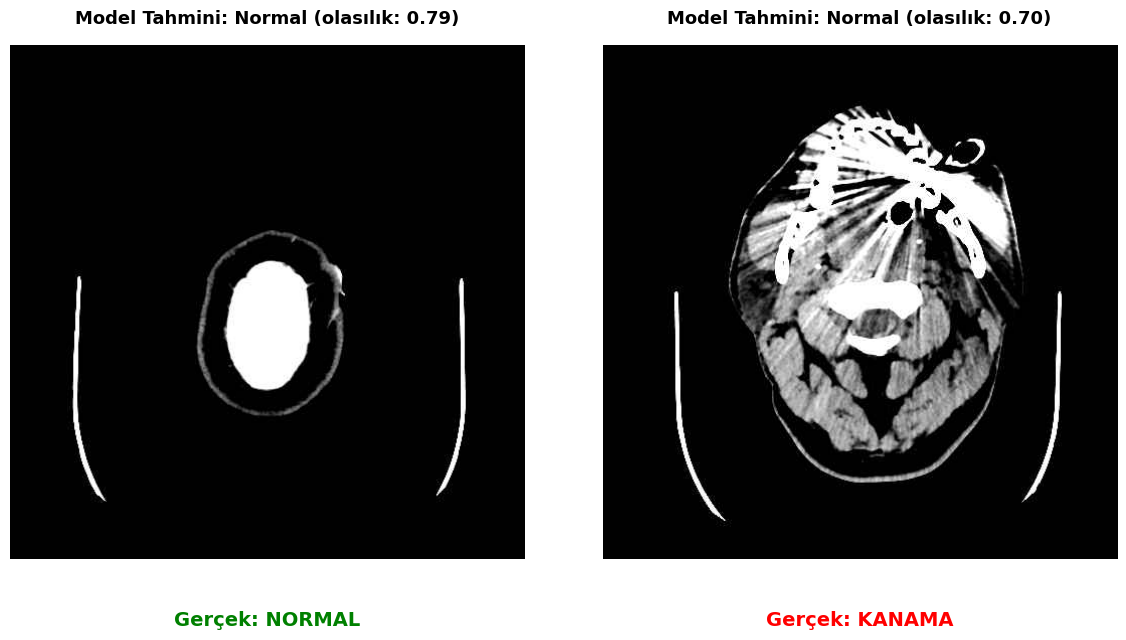

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_resnet50.eval()
model_resnet50 = model_resnet50.to(device)


resim_yollari = [
    '/content/drive/MyDrive/Data/NORMAL/N12[N12]/N12_0_10.jpg',
    '/content/drive/MyDrive/Data/Hemorrhagic/KANAMA/12[12]/12_0_0.jpg'
]

siniflar = ['Normal', 'Kanama VAR']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

plt.figure(figsize=(12, 6))
for idx, yol in enumerate(resim_yollari):
    orijinal_resim = Image.open(yol).convert('RGB')
    input_tensor = transform(orijinal_resim).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model_resnet50(input_tensor)
        olasiliklar = F.softmax(output, dim=1)
        olasilik_degeri, tahmin_indeksi = torch.max(olasiliklar, 1)


        olasilik_float = olasilik_degeri.item()
        tahmin_idx = tahmin_indeksi.item()

    ax = plt.subplot(1, 2, idx + 1)
    ax.axis('off')
    ax.imshow(orijinal_resim)
    ax.set_title(f"Model Tahmini: {siniflar[tahmin_idx]} (olasılık: {olasilik_float:.2f})",
                 fontsize=13, pad=15, weight='bold')

    gercek_etiket = 'NORMAL' if 'NORMAL' in yol.upper() else 'KANAMA'
    renk = 'green' if siniflar[tahmin_idx].upper() == gercek_etiket else 'red'
    ax.text(0.5, -0.12, f"Gerçek: {gercek_etiket}", transform=ax.transAxes,
            ha="center", va="center", fontsize=14, weight='bold', color=renk)

plt.tight_layout()
plt.show()